Task 1

In [1]:
!pip install -q kagglehub
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 6)
dataset_path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset downloaded to:")
print(dataset_path)
metadata_files = glob.glob(
    os.path.join(
        dataset_path,
        "**",
        "HAM10000_metadata.csv"
    ),
    recursive=True
)

image_files = glob.glob(
    os.path.join(
        dataset_path,
        "**",
        "*.jpg"
    ),
    recursive=True
)

print("Number of images:", len(image_files))
print("Metadata files:", len(metadata_files))
metadata_path = metadata_files[0]

metadata = pd.read_csv(
    metadata_path
)

image_map = {
    os.path.splitext(
        os.path.basename(path)
    )[0]: path
    for path in image_files
}

metadata["image_path"] = (
    metadata["image_id"]
    .map(image_map)
)

metadata = metadata.dropna(
    subset=["image_path"]
).reset_index(drop=True)

print(
    "Images available:",
    len(metadata)
)

display(
    metadata.head()
)
selected_classes = [
    "mel",
    "nv",
    "bkl",
    "bcc",
    "akiec"
]

selected_rows = []

for i, class_name in enumerate(
    selected_classes
):

    candidates = metadata[
        metadata["dx"] == class_name
    ]

    if len(candidates) > 0:

        selected_rows.append(
            candidates.sample(
                1,
                random_state=42 + i
            ).iloc[0]
        )

selected = pd.DataFrame(
    selected_rows
).reset_index(drop=True)

selected["Image"] = [
    f"Image {i+1}"
    for i in range(len(selected))
]

display(
    selected[
        [
            "Image",
            "image_id",
            "dx"
        ]
    ]
)
selected_classes = [
    "mel",
    "nv",
    "bkl",
    "bcc",
    "akiec"
]

selected_rows = []

for i, class_name in enumerate(
    selected_classes
):

    candidates = metadata[
        metadata["dx"] == class_name
    ]

    if len(candidates) > 0:

        selected_rows.append(
            candidates.sample(
                1,
                random_state=42 + i
            ).iloc[0]
        )

selected = pd.DataFrame(
    selected_rows
).reset_index(drop=True)

selected["Image"] = [
    f"Image {i+1}"
    for i in range(len(selected))
]

display(
    selected[
        [
            "Image",
            "image_id",
            "dx"
        ]
    ]
)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to:
/kaggle/input/skin-cancer-mnist-ham10000
Number of images: 20030
Metadata files: 1
Images available: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


,Image,image_id,dx
0,Image 1,ISIC_0028847,mel
1,Image 2,ISIC_0028776,nv
2,Image 3,ISIC_0031226,bkl
3,Image 4,ISIC_0029123,bcc
4,Image 5,ISIC_0030297,akiec


,Image,image_id,dx
0,Image 1,ISIC_0028847,mel
1,Image 2,ISIC_0028776,nv
2,Image 3,ISIC_0031226,bkl
3,Image 4,ISIC_0029123,bcc
4,Image 5,ISIC_0030297,akiec


Task 2

Image shape: (450, 600, 3)
Grayscale shape: (450, 600)


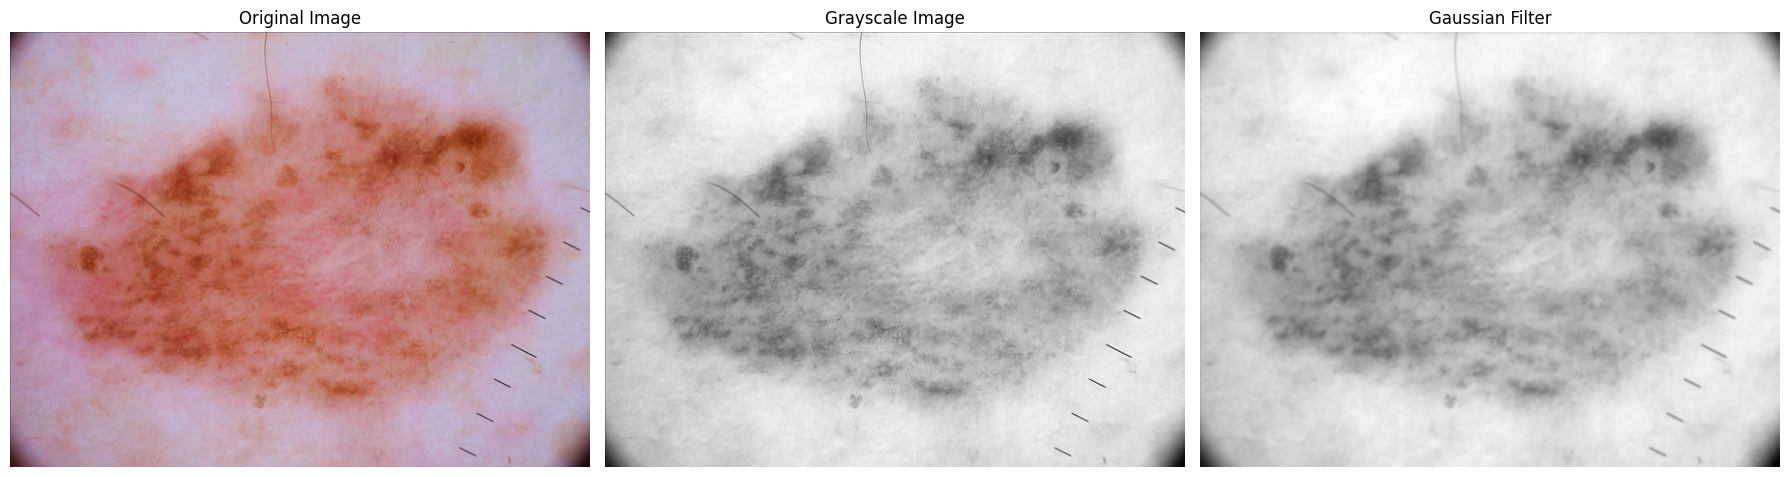

In [2]:
row = selected.iloc[0]

image = cv2.imread(
    row["image_path"]
)

print(
    "Image shape:",
    image.shape
)
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)
print(
    "Grayscale shape:",
    gray.shape
)
gaussian = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

axes[0].imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

axes[0].set_title(
    "Original Image"
)

axes[1].imshow(
    gray,
    cmap="gray"
)

axes[1].set_title(
    "Grayscale Image"
)

axes[2].imshow(
    gaussian,
    cmap="gray"
)

axes[2].set_title(
    "Gaussian Filter"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


Task 3

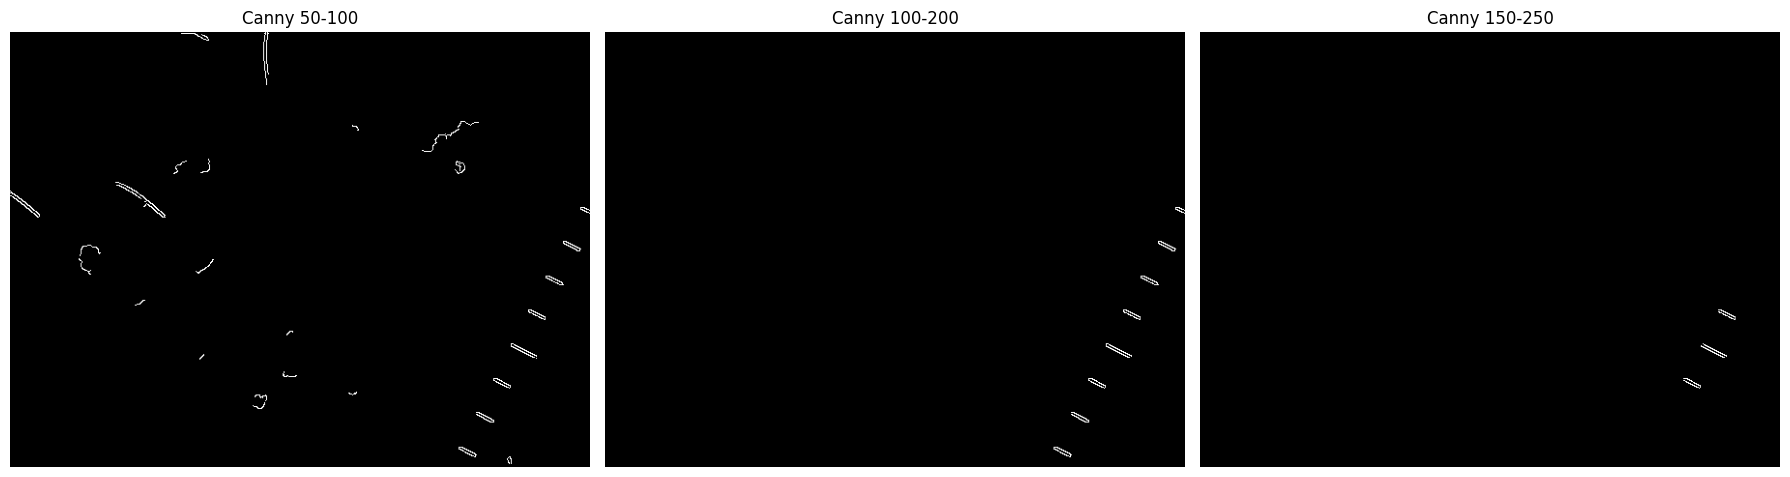

In [3]:
canny_50_100 = cv2.Canny(
    gaussian,
    50,
    100
)
canny_100_200 = cv2.Canny(
    gaussian,
    100,
    200
)
canny_150_250 = cv2.Canny(
    gaussian,
    150,
    250
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

axes[0].imshow(
    canny_50_100,
    cmap="gray"
)

axes[0].set_title(
    "Canny 50-100"
)

axes[1].imshow(
    canny_100_200,
    cmap="gray"
)

axes[1].set_title(
    "Canny 100-200"
)

axes[2].imshow(
    canny_150_250,
    cmap="gray"
)

axes[2].set_title(
    "Canny 150-250"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


Task 4

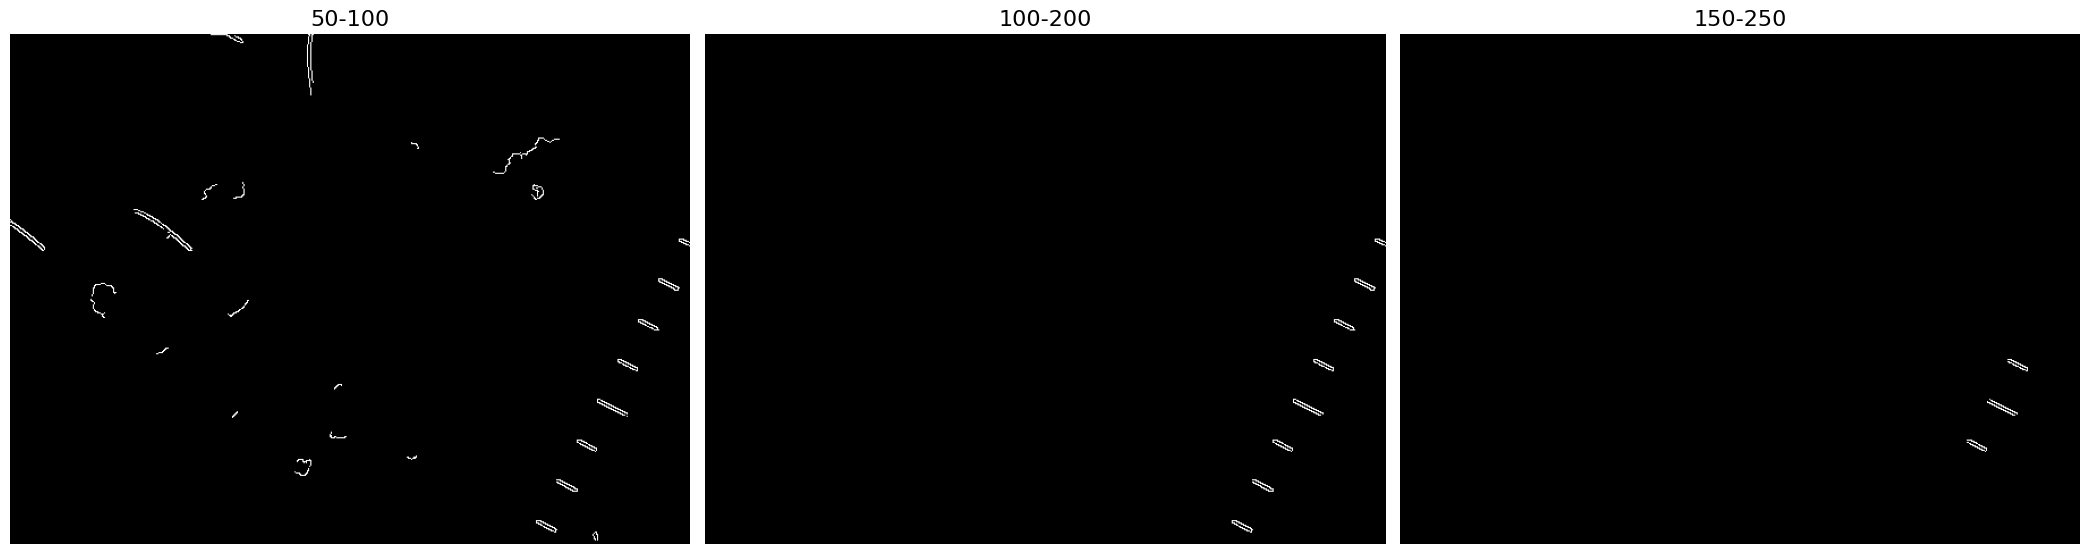

Selected Canny threshold: 100-200

The Canny threshold of 100-200 was selected because it provides
a good balance between detecting the lesion boundary and reducing
unwanted noise. The 50-100 setting detects more weak edges and
noise, while 150-250 can remove some weaker parts of the lesion
boundary.



In [4]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)
axes[0].imshow(
    canny_50_100,
    cmap="gray"
)
axes[0].set_title(
    "50-100",
    fontsize=16
)
axes[1].imshow(
    canny_100_200,
    cmap="gray"
)
axes[1].set_title(
    "100-200",
    fontsize=16
)
axes[2].imshow(
    canny_150_250,
    cmap="gray"
)
axes[2].set_title(
    "150-250",
    fontsize=16
)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
best_low = 100
best_high = 200

best_edges = cv2.Canny(
    gaussian,
    best_low,
    best_high
)

print(
    "Selected Canny threshold:",
    f"{best_low}-{best_high}"
)
print("""
The Canny threshold of 100-200 was selected because it provides
a good balance between detecting the lesion boundary and reducing
unwanted noise. The 50-100 setting detects more weak edges and
noise, while 150-250 can remove some weaker parts of the lesion
boundary.
""")

Task 5

In [8]:
!pip install -q kaggle

Selected Canny Threshold: (30, 80)


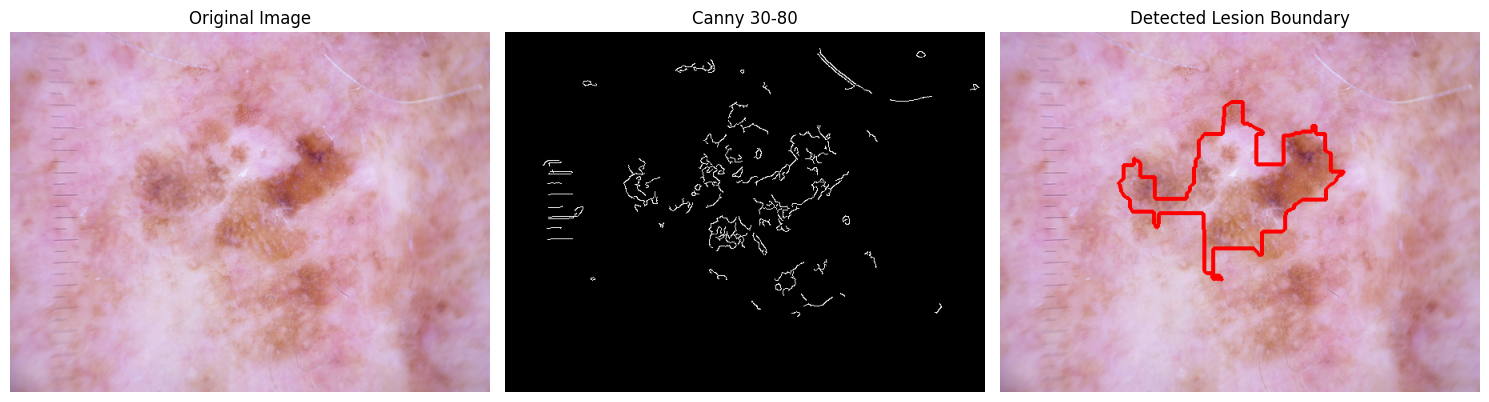

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_name = "ISIC_0027419.jpg"

paths = [
    f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/{image_name}",
    f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/{image_name}"
]

image_path = None

for path in paths:
    if os.path.exists(path):
        image_path = path
        break

if image_path is None:
    raise FileNotFoundError(
        "Image not found. Check the image name and dataset path."
    )

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image could not be loaded.")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

thresholds = [
    (50, 100),
    (100, 200),
    (150, 250)
]

best_contour = None
best_edges = None
best_threshold = None
best_area = 0

image_area = image.shape[0] * image.shape[1]

for low, high in thresholds:

    edges = cv2.Canny(
        blurred,
        low,
        high
    )

    kernel = np.ones(
        (7, 7),
        np.uint8
    )

    processed_edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    processed_edges = cv2.dilate(
        processed_edges,
        kernel,
        iterations=1
    )

    contours, _ = cv2.findContours(
        processed_edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        area = cv2.contourArea(contour)

        if (
            area > image_area * 0.01
            and area < image_area * 0.80
            and area > best_area
        ):
            best_area = area
            best_contour = contour
            best_edges = edges
            best_threshold = (low, high)

if best_contour is None:

    edges = cv2.Canny(
        blurred,
        30,
        80
    )

    kernel = np.ones(
        (9, 9),
        np.uint8
    )

    processed_edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=4
    )

    contours, _ = cv2.findContours(
        processed_edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        raise ValueError(
            "No contour could be detected. Try another HAM10000 image."
        )

    valid_contours = [
        c for c in contours
        if image_area * 0.005 < cv2.contourArea(c) < image_area * 0.90
    ]

    if len(valid_contours) == 0:
        valid_contours = contours

    best_contour = max(
        valid_contours,
        key=cv2.contourArea
    )

    best_edges = edges
    best_threshold = (30, 80)

boundary_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

cv2.drawContours(
    boundary_image,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

print("Selected Canny Threshold:", best_threshold)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(best_edges, cmap="gray")
plt.title(f"Canny {best_threshold[0]}-{best_threshold[1]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(boundary_image)
plt.title("Detected Lesion Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()

Task 6

TASK 6 - LESION MEASUREMENTS
Image: ISIC_0027419.jpg
Best Canny Threshold: (30, 80)
Lesion Area: 18780.0 pixels
Lesion Perimeter: 1012.96 pixels


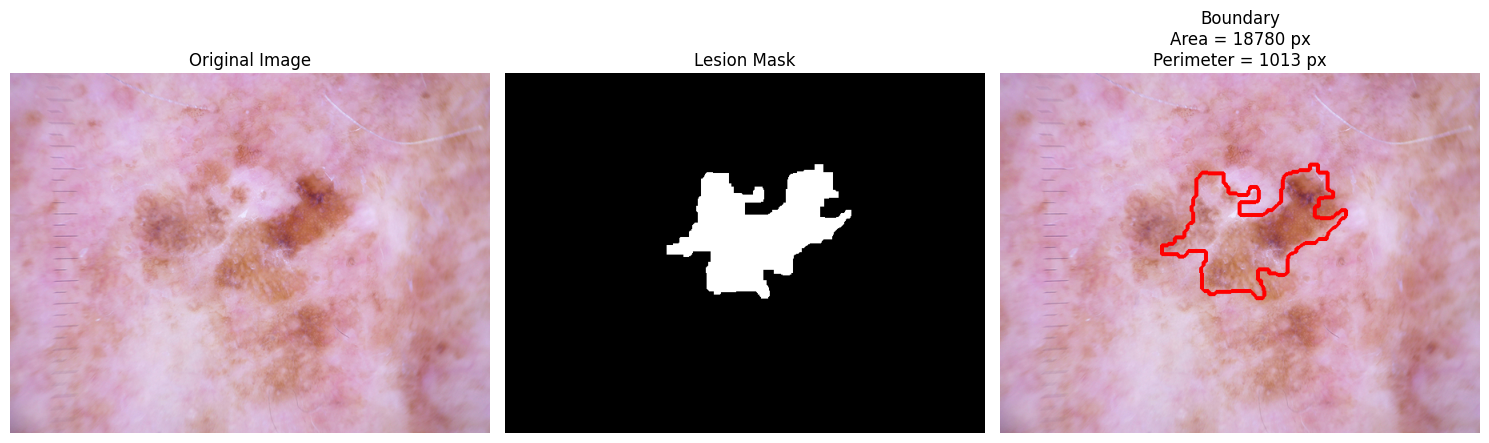

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_name = "ISIC_0027419.jpg"

paths = [
    f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/{image_name}",
    f"/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/{image_name}"
]

image_path = None

for path in paths:
    if os.path.exists(path):
        image_path = path
        break

if image_path is None:
    raise FileNotFoundError(
        "Image not found. Check the image name and dataset path."
    )

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image could not be loaded.")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

image_area = image.shape[0] * image.shape[1]

thresholds = [
    (50, 100),
    (100, 200),
    (150, 250),
    (30, 80)
]

best_contour = None
best_edges = None
best_threshold = None
best_area = 0

for low, high in thresholds:

    edges = cv2.Canny(
        blurred,
        low,
        high
    )

    kernel = np.ones(
        (7, 7),
        np.uint8
    )

    processed_edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    processed_edges = cv2.dilate(
        processed_edges,
        kernel,
        iterations=1
    )

    contours, _ = cv2.findContours(
        processed_edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        area = cv2.contourArea(contour)

        if (
            area > image_area * 0.005
            and area < image_area * 0.90
            and area > best_area
        ):
            best_area = area
            best_contour = contour
            best_edges = edges
            best_threshold = (low, high)

if best_contour is None:
    raise ValueError(
        "No suitable lesion boundary was detected. Try another image."
    )

lesion_area = cv2.contourArea(
    best_contour
)

lesion_perimeter = cv2.arcLength(
    best_contour,
    True
)

mask = np.zeros(
    gray.shape,
    dtype=np.uint8
)

cv2.drawContours(
    mask,
    [best_contour],
    -1,
    255,
    thickness=cv2.FILLED
)

boundary_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

cv2.drawContours(
    boundary_image,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

print("=" * 45)
print("TASK 6 - LESION MEASUREMENTS")
print("=" * 45)
print("Image:", image_name)
print("Best Canny Threshold:", best_threshold)
print("Lesion Area:", round(lesion_area, 2), "pixels")
print("Lesion Perimeter:", round(lesion_perimeter, 2), "pixels")
print("=" * 45)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Lesion Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(boundary_image)
plt.title(
    f"Boundary\nArea = {lesion_area:.0f} px\nPerimeter = {lesion_perimeter:.0f} px"
)
plt.axis("off")

plt.tight_layout()
plt.show()